## Importing Libraries and Datasets
Importing the necessary libraries and reading in the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import RobustScaler

credit_record = pd.read_csv("credit_record.csv")
application_record = pd.read_csv("application_record.csv")


In [ ]:
credit_record.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


`MONTHS_BALANCE` shows us the time reference for the data, where 0 is the current month, and -1 indicates the previous month. This column allows us to see how an applicant's status has changed over time.

`STATUS` is a categorical variable indicating the applicant's loan status on that current month. `X` suggests that there was no loan taken on that month, `C` suggests that the loan was paid off that month and `0` to `5` indicates how many months the loan is overdue, with `0` (1-29 days overdue) being the least and `5` (more than 150 days overdue) being the most.

In [ ]:
application_record.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


The `credit_record.info()` and `application_record.info()` commands display a summary of their respective dataset, including the column names, data types, and non-null value counts for each column.

In [ ]:
credit_record.info(), application_record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-

(None, None)

Check the size of each of the datasets:

`credit_record` has 1,048,575 rows and 3 columns, meaning it contains over a million records, each with 3 features.

`application_record` has 438,557 rows and 18 columns, meaning it contains over 400,000 records, each with 18 features.

In [ ]:
print("credit_record:",credit_record.shape)
print("application_record:",application_record.shape)

credit_record: (1048575, 3)
application_record: (438557, 18)


## Checking for duplicates and NA values

### Check for duplicates:

There are no complete duplicate rows in either of the datasets

In [ ]:
credit_record.duplicated().sum(), application_record.duplicated().sum()

(0, 0)

### Check for duplicates in the `ID` column:

In [ ]:
id_counts = application_record['ID'].value_counts()
# filter for id counts that are > 1
id_counts = id_counts[id_counts > 1]
num_duplicate_ids = application_record['ID'].duplicated(keep=False).sum()

print(id_counts.head())
print(f"Total number of duplicate IDs: {num_duplicate_ids}")

ID
7137299    2
7702238    2
7282535    2
7243768    2
7050948    2
Name: count, dtype: int64
Total number of duplicate IDs: 94


Seems like there are 94 IDs with multiple entries. We will investigate the rows with the same ID below.

In [ ]:
# investigate the rows with the same ID
application_record[application_record['ID'].isin(id_counts.index)].sort_values('ID')

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
426818,7022197,M,Y,Y,3,135000.0,Working,Secondary / secondary special,Married,House / apartment,-11945,-735,1,0,0,1,Laborers,5.0
425023,7022197,F,N,Y,0,450000.0,Commercial associate,Higher education,Separated,House / apartment,-19813,-1799,1,0,0,1,NaN,1.0
431545,7022327,F,N,Y,0,135000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-14771,-5298,1,0,0,0,High skill tech staff,1.0
431911,7022327,M,Y,Y,0,256500.0,Commercial associate,Higher education,Married,House / apartment,-21503,-1674,1,0,0,1,Core staff,2.0
425486,7023108,M,Y,Y,1,67500.0,Working,Secondary / secondary special,Married,House / apartment,-15156,-1696,1,1,0,0,Core staff,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426563,7836711,F,N,Y,2,292500.0,Working,Higher education,Married,House / apartment,-13747,-4386,1,0,1,0,Accountants,4.0
421464,7836971,M,Y,N,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,-13771,-5520,1,0,0,0,NaN,3.0
428620,7836971,F,N,Y,0,103500.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-13383,-2798,1,0,1,0,Sales staff,2.0
422068,7838075,M,N,Y,0,337500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-18198,-1275,1,0,0,1,Drivers,2.0


These duplicate IDs could be due to people being in the same family. Hence, we should find out many of these duplicate IDs have different `CNT_FAM_MEMBERS`(Family size) and keep only the first occurence of these families.

In [ ]:
duplicate_ids = application_record['ID'].duplicated(keep=False)
duplicate_families = application_record[duplicate_ids][['ID', 'CNT_FAM_MEMBERS']].groupby('ID')['CNT_FAM_MEMBERS'].nunique()
duplicate_families = duplicate_families[duplicate_families > 1].sum()
print(duplicate_families)

56


There are 56 instances where the same `ID` has different values for `CNT_FAM_MEMBERS` (family size).

In [ ]:
application_record = application_record.sort_values('CNT_FAM_MEMBERS')
application_record = application_record.drop_duplicates(subset='ID', keep='first')

In [ ]:
print("application_record:",application_record.shape)

application_record: (438510, 18)


47 rows were dropped.

### Check for NA values:

In [ ]:
credit_record.isna().sum(), application_record.isna().sum()

(ID                0
 MONTHS_BALANCE    0
 STATUS            0
 dtype: int64,
 ID                          0
 CODE_GENDER                 0
 FLAG_OWN_CAR                0
 FLAG_OWN_REALTY             0
 CNT_CHILDREN                0
 AMT_INCOME_TOTAL            0
 NAME_INCOME_TYPE            0
 NAME_EDUCATION_TYPE         0
 NAME_FAMILY_STATUS          0
 NAME_HOUSING_TYPE           0
 DAYS_BIRTH                  0
 DAYS_EMPLOYED               0
 FLAG_MOBIL                  0
 FLAG_WORK_PHONE             0
 FLAG_PHONE                  0
 FLAG_EMAIL                  0
 OCCUPATION_TYPE        134193
 CNT_FAM_MEMBERS             0
 dtype: int64)

There are no NA values in the `credit_record` dataset.

In the `application_record` dataset, there are NA values only in the `OCCUPATION_TYPE` column. However, in which there are 134203 rows which makes up almost 30% of the dataset. Thus, it is not feasible to drop the rows.

## Converting columns

In [ ]:
credit_record.nunique(), application_record.nunique()

(ID                45985
 MONTHS_BALANCE       61
 STATUS                8
 dtype: int64,
 ID                     438510
 CODE_GENDER                 2
 FLAG_OWN_CAR                2
 FLAG_OWN_REALTY             2
 CNT_CHILDREN               12
 AMT_INCOME_TOTAL          866
 NAME_INCOME_TYPE            5
 NAME_EDUCATION_TYPE         5
 NAME_FAMILY_STATUS          5
 NAME_HOUSING_TYPE           6
 DAYS_BIRTH              16379
 DAYS_EMPLOYED            9406
 FLAG_MOBIL                  1
 FLAG_WORK_PHONE             2
 FLAG_PHONE                  2
 FLAG_EMAIL                  2
 OCCUPATION_TYPE            18
 CNT_FAM_MEMBERS            13
 dtype: int64)

The `FLAG_MOBIL` (Is there a mobile phone) column in `application_record` has only 1 unique value. It can be dropped without affecting our analysis.

In [ ]:
application_record = application_record.drop('FLAG_MOBIL', axis=1)

Here, we are finding out the frequency distribution of values for both the number of children (`CNT_CHILDREN`) and the family size (`CNT_FAM_MEMBERS`) in the dataset.

In [ ]:
application_record['CNT_CHILDREN'].value_counts(), application_record['CNT_FAM_MEMBERS'].value_counts()

(CNT_CHILDREN
 0     304047
 1      88514
 2      39875
 3       5429
 4        486
 5        133
 7          9
 9          5
 6          4
 12         4
 14         3
 19         1
 Name: count, dtype: int64,
 CNT_FAM_MEMBERS
 2.0     233868
 1.0      84490
 3.0      77116
 4.0      37347
 5.0       5080
 6.0        459
 7.0        124
 9.0          9
 11.0         5
 8.0          4
 14.0         4
 15.0         3
 20.0         1
 Name: count, dtype: int64)

Convert `CNT_CHILDREN` into a categorical variable (`NUM_CHILDREN`) with unique values "0", "1", "2" , where each value represents the number of children, but "2" represents 2 or more children

Similarly, convert `CNT_FAM_MEMBERS` into a categorical variable (`NUM_FAM`) with unique values "1", "2", "3", "4", where each value represents the number of family members, but "4" represents 4 or more family members

In [ ]:
application_record['NUM_CHILDREN'] = application_record['CNT_CHILDREN'].apply(lambda x: '0' if x == 0 else '1' if x == 1 else '2 or more')
application_record['NUM_FAM'] = application_record['CNT_FAM_MEMBERS'].apply(lambda x: '1' if x == 1 else '2' if x == 2 else '3' if x == 3 else '4')


application_record['NUM_CHILDREN'].value_counts(), application_record['NUM_FAM'].value_counts()

(NUM_CHILDREN
 0            304047
 1             88514
 2 or more     45949
 Name: count, dtype: int64,
 NUM_FAM
 2    233868
 1     84490
 3     77116
 4     43036
 Name: count, dtype: int64)

In [ ]:
# drop CNT_CHILDREN and CNT_FAM_MEMBERS
application_record = application_record.drop(['CNT_CHILDREN', 'CNT_FAM_MEMBERS'], axis=1)

Convert the above 2 columns as well as columns that have only 2 unique values such as `CODE_GENDER` and `FLAG_OWN_CAR`, etc. into categorical type for more memory efficiency.

In [ ]:
columns_to_convert = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'NUM_CHILDREN', 'NUM_FAM']
application_record[columns_to_convert] = application_record[columns_to_convert].apply(pd.Categorical)

application_record.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438510 entries, 103805 to 36388
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   ID                   438510 non-null  int64   
 1   CODE_GENDER          438510 non-null  category
 2   FLAG_OWN_CAR         438510 non-null  category
 3   FLAG_OWN_REALTY      438510 non-null  category
 4   AMT_INCOME_TOTAL     438510 non-null  float64 
 5   NAME_INCOME_TYPE     438510 non-null  object  
 6   NAME_EDUCATION_TYPE  438510 non-null  object  
 7   NAME_FAMILY_STATUS   438510 non-null  object  
 8   NAME_HOUSING_TYPE    438510 non-null  object  
 9   DAYS_BIRTH           438510 non-null  int64   
 10  DAYS_EMPLOYED        438510 non-null  int64   
 11  FLAG_WORK_PHONE      438510 non-null  category
 12  FLAG_PHONE           438510 non-null  category
 13  FLAG_EMAIL           438510 non-null  category
 14  OCCUPATION_TYPE      304317 non-null  object  
 15  N

In [ ]:
# convert DAYS_BIRTH into age and DAYS_EMPLOYED into years
application_record['AGE'] = (application_record['DAYS_BIRTH'] // -365)
application_record['EMPLOYMENT_DURATION'] = (application_record['DAYS_EMPLOYED'] // -365)
application_record = application_record.drop(['DAYS_BIRTH', 'DAYS_EMPLOYED'], axis=1)

application_record.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,NUM_CHILDREN,NUM_FAM,AGE,EMPLOYMENT_DURATION
103805,5436053,F,N,Y,180000.0,Working,Secondary / secondary special,Separated,House / apartment,0,0,0,NaN,0,1,50,9
248783,6047044,M,Y,N,270000.0,State servant,Higher education,Single / not married,Office apartment,0,1,1,NaN,0,1,36,6
248782,6047043,M,Y,N,270000.0,State servant,Higher education,Single / not married,Office apartment,0,1,1,NaN,0,1,36,6
248781,6047042,M,Y,N,270000.0,State servant,Higher education,Single / not married,Office apartment,0,1,1,NaN,0,1,36,6
248780,6047041,M,Y,N,270000.0,State servant,Higher education,Single / not married,Office apartment,0,1,1,NaN,0,1,36,6


In [ ]:
application_record.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438510 entries, 103805 to 36388
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   ID                   438510 non-null  int64   
 1   CODE_GENDER          438510 non-null  category
 2   FLAG_OWN_CAR         438510 non-null  category
 3   FLAG_OWN_REALTY      438510 non-null  category
 4   AMT_INCOME_TOTAL     438510 non-null  float64 
 5   NAME_INCOME_TYPE     438510 non-null  object  
 6   NAME_EDUCATION_TYPE  438510 non-null  object  
 7   NAME_FAMILY_STATUS   438510 non-null  object  
 8   NAME_HOUSING_TYPE    438510 non-null  object  
 9   FLAG_WORK_PHONE      438510 non-null  category
 10  FLAG_PHONE           438510 non-null  category
 11  FLAG_EMAIL           438510 non-null  category
 12  OCCUPATION_TYPE      304317 non-null  object  
 13  NUM_CHILDREN         438510 non-null  category
 14  NUM_FAM              438510 non-null  category
 15  A

In [ ]:
for column in ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']:
    print(f"Value counts for {column}:")
    print(application_record[column].value_counts())
    print()

Value counts for NAME_INCOME_TYPE:
NAME_INCOME_TYPE
Working                 226081
Commercial associate    100738
Pensioner                75488
State servant            36186
Student                     17
Name: count, dtype: int64

Value counts for NAME_EDUCATION_TYPE:
NAME_EDUCATION_TYPE
Secondary / secondary special    301789
Higher education                 117510
Incomplete higher                 14848
Lower secondary                    4051
Academic degree                     312
Name: count, dtype: int64

Value counts for NAME_FAMILY_STATUS:
NAME_FAMILY_STATUS
Married                 299791
Single / not married     55268
Civil marriage           36525
Separated                27251
Widow                    19675
Name: count, dtype: int64

Value counts for NAME_HOUSING_TYPE:
NAME_HOUSING_TYPE
House / apartment      393789
With parents            19075
Municipal apartment     14211
Rented apartment         5974
Office apartment         3922
Co-op apartment          1539
Name: cou

Checking for logically inconsistent / data out of expected range for numerical columns

In [ ]:
application_record.describe()

,ID,AMT_INCOME_TOTAL,AGE,EMPLOYMENT_DURATION
count,4.385100e+05,4.385100e+05,438510.000000,438510.000000
mean,6.022035e+06,1.875226e+05,43.326647,-166.408200
std,5.714962e+05,1.100835e+05,11.467608,380.128672
min,5.008804e+06,2.610000e+04,20.000000,-1001.000000
25%,5.609362e+06,1.215000e+05,34.000000,1.000000
50%,6.047720e+06,1.607805e+05,42.000000,4.000000
75%,6.454161e+06,2.250000e+05,53.000000,8.000000
max,7.999952e+06,6.750000e+06,69.000000,48.000000


Unusual entry under `EMPLOYMENT_DURATION` where the minimum is -1001 years.

In [ ]:
application_record[application_record['EMPLOYMENT_DURATION'] == -1001].head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,NUM_CHILDREN,NUM_FAM,AGE,EMPLOYMENT_DURATION
317849,6262303,F,N,Y,211500.0,Pensioner,Secondary / secondary special,Single / not married,House / apartment,0,1,1,NaN,0,1,63,-1001
170522,5804948,F,N,Y,225000.0,Pensioner,Higher education,Single / not married,House / apartment,0,0,0,NaN,0,1,66,-1001
170523,5804949,F,N,Y,225000.0,Pensioner,Higher education,Single / not married,House / apartment,0,0,0,NaN,0,1,66,-1001
170524,5804951,F,N,Y,225000.0,Pensioner,Higher education,Single / not married,House / apartment,0,0,0,NaN,0,1,66,-1001
170525,5804952,F,N,Y,225000.0,Pensioner,Higher education,Single / not married,House / apartment,0,0,0,NaN,0,1,66,-1001


According to the dataset description, a negative value for `EMPLOYMENT_DURATION` means that the person is currently unemployed. We will explore this data subset below.

In [ ]:
# Exploring the income types and occupations of these unemployed applicants
income_type = application_record[application_record['EMPLOYMENT_DURATION']<0]['NAME_INCOME_TYPE'].unique()
occupation_type = application_record[application_record['EMPLOYMENT_DURATION']<0]['OCCUPATION_TYPE'].unique()
print("Income types:", income_type,
      "\nOccupation types:", occupation_type)

Income types: ['Pensioner'] 
Occupation types: [nan]


It seems that applicants who are currently unemployed receive pension and take on the NA value in `OCCUPATION_TYPE`. We will convert these NA values to a new value `None` to differentiate unemployed applicants from applicants with missing `OCCUPATION_TYPE` values.

In [ ]:
application_record['OCCUPATION_TYPE'] = np.where(application_record['EMPLOYMENT_DURATION'] < 0, 'None', application_record['OCCUPATION_TYPE'])
application_record[application_record['EMPLOYMENT_DURATION'] < 0].head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,NUM_CHILDREN,NUM_FAM,AGE,EMPLOYMENT_DURATION
317849,6262303,F,N,Y,211500.0,Pensioner,Secondary / secondary special,Single / not married,House / apartment,0,1,1,None,0,1,63,-1001
170522,5804948,F,N,Y,225000.0,Pensioner,Higher education,Single / not married,House / apartment,0,0,0,None,0,1,66,-1001
170523,5804949,F,N,Y,225000.0,Pensioner,Higher education,Single / not married,House / apartment,0,0,0,None,0,1,66,-1001
170524,5804951,F,N,Y,225000.0,Pensioner,Higher education,Single / not married,House / apartment,0,0,0,None,0,1,66,-1001
170525,5804952,F,N,Y,225000.0,Pensioner,Higher education,Single / not married,House / apartment,0,0,0,None,0,1,66,-1001


Check the distribution of `AMT_INCOME_TOTAL` in `application_record`

<Axes: xlabel='AMT_INCOME_TOTAL'>

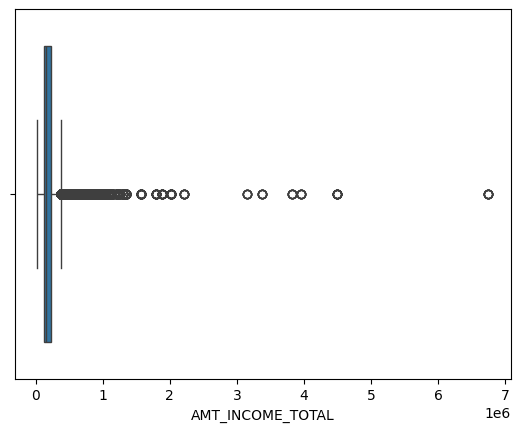

In [ ]:
sns.boxplot(x=application_record['AMT_INCOME_TOTAL'])

Scale the feature 'AMT_INCOME_TOTAL' with RobustScaler to help reduce the impact of outliers and improve model performance.

In [ ]:
scaler = RobustScaler()
application_record['INCOME_SCALED'] = scaler.fit_transform(application_record[['AMT_INCOME_TOTAL']])

## Converting STATUS column in credit_record

In [ ]:
credit_record['STATUS'].value_counts()

,count
STATUS,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


According to this [link](https://www.mas.gov.sg/regulation/explainers/ongoing-credit-checks-and-requirements/borrowers-who-are-60-days-past-due) by the Monetary Authority of Singapore, "Financial institutions cannot grant further unsecured credit to borrowers who are 60 days past due on any credit card or unsecured credit facility.".


---


Hence, our approach is as follows:

1) Initial Classification (Based on MONTHS_BALANCE = 0):

- Bad (1): If STATUS = 2, 3, 4, or 5.

- Good (0): If STATUS = 0, C, or X.

- Intermediate: If STATUS = 1.

2) Handling intermediate clients
- Count the total number of overdue months where STATUS is 1, 2, 3, 4, or 5.
If the sum is greater than 1 and the last overdue month is within 2 months from the most recent overdue month, classify as "Bad" (1)
- Example: the client had an overdue status in January (STATUS = 1), paid off in February (STATUS = C), and was overdue again in March (STATUS = 1). For this client, the total overdue months = 2 > 1 and the last overdue month (January) is within the most recent overdue month (March). Return 1 (classify as "Bad").

Over here, '1' means the applicant is a "bad" client, while '0' means the applicant is a "good" client.

In [ ]:
# Ensure that the data is sorted by ID and MONTHS_BALANCE
credit_record = credit_record.sort_values(['ID', 'MONTHS_BALANCE'], ascending=[True, False])

def classify_client(client):
    # Initial classification based on the most recent month (MONTHS_BALANCE = 0)
    most_recent = client[client['MONTHS_BALANCE'] == 0]

    if len(most_recent) > 0:
        status = most_recent['STATUS'].iloc[0]
        if status in ['2', '3', '4', '5']:
            return '1'
        elif status in ['0', 'C', 'X']:
            return '0'

    overdue_months = client[client['STATUS'].isin(['1', '2', '3', '4', '5'])]

    if len(overdue_months) > 1:
        last_overdue = overdue_months['MONTHS_BALANCE'].iloc[-1]
        most_recent_overdue = overdue_months['MONTHS_BALANCE'].iloc[0]

        if most_recent_overdue - last_overdue <= 2:
            return '1'

    return '0'

# Apply the function to each client
result = credit_record.groupby('ID').apply(classify_client).reset_index()
result.columns = ['ID', 'Classification']

result['Classification'].value_counts()

<ipython-input-23-acd05340aa9d>:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = credit_record.groupby('ID').apply(classify_client).reset_index()


,count
Classification,
0,45617
1,368


In [ ]:
result.head()

,ID,Classification
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


Merge `result` to the `application_record` dataset based on ID

In [ ]:
application_record = application_record.merge(result, on='ID', how='inner')
application_record.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,NUM_CHILDREN,NUM_FAM,AGE,EMPLOYMENT_DURATION,INCOME_SCALED,Classification
0,5149805,F,N,Y,135000.0,State servant,Incomplete higher,Single / not married,With parents,0,1,1,NaN,0,1,27,5,-0.249087,0
1,5149804,F,N,Y,135000.0,State servant,Incomplete higher,Single / not married,With parents,0,1,1,NaN,0,1,27,5,-0.249087,0
2,5149803,F,N,Y,135000.0,State servant,Incomplete higher,Single / not married,With parents,0,1,1,NaN,0,1,27,5,-0.249087,0
3,5149802,F,N,Y,135000.0,State servant,Incomplete higher,Single / not married,With parents,0,1,1,NaN,0,1,27,5,-0.249087,0
4,5149801,F,N,Y,135000.0,State servant,Incomplete higher,Single / not married,With parents,0,1,1,NaN,0,1,27,5,-0.249087,0


In [ ]:
application_record['Classification'].value_counts()

,count
Classification,
0,36113
1,344


In [ ]:
application_record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ID                   36457 non-null  int64   
 1   CODE_GENDER          36457 non-null  category
 2   FLAG_OWN_CAR         36457 non-null  category
 3   FLAG_OWN_REALTY      36457 non-null  category
 4   AMT_INCOME_TOTAL     36457 non-null  float64 
 5   NAME_INCOME_TYPE     36457 non-null  object  
 6   NAME_EDUCATION_TYPE  36457 non-null  object  
 7   NAME_FAMILY_STATUS   36457 non-null  object  
 8   NAME_HOUSING_TYPE    36457 non-null  object  
 9   FLAG_WORK_PHONE      36457 non-null  category
 10  FLAG_PHONE           36457 non-null  category
 11  FLAG_EMAIL           36457 non-null  category
 12  OCCUPATION_TYPE      31269 non-null  object  
 13  NUM_CHILDREN         36457 non-null  category
 14  NUM_FAM              36457 non-null  category
 15  AGE                

## Handling Imbalanced Data

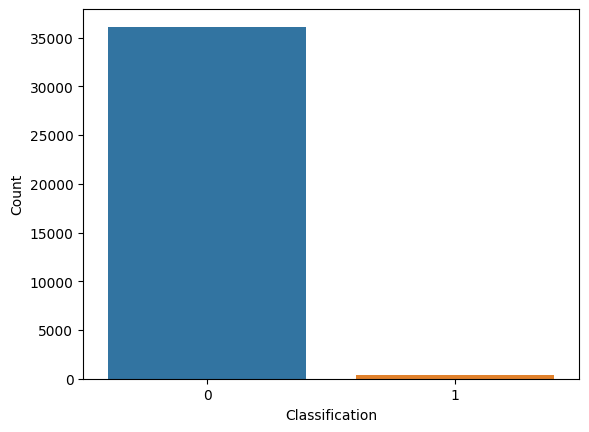

In [ ]:
count = application_record['Classification'].value_counts()
fig = sns.barplot(x=count.index, y=count.values, hue = count.index).set(xlabel='Classification', ylabel='Count')